In [1]:
from IPython.display import HTML
HTML('''
    <style> body {font-family: "Roboto Condensed Light", "Roboto Condensed";} h2 {padding: 10px 12px; background-color: #E64626; position: static; color: #ffffff; font-size: 40px;} .text_cell_render p { font-size: 15px; } .text_cell_render h1 { font-size: 30px; } h1 {padding: 10px 12px; background-color: #E64626; color: #ffffff; font-size: 40px;} .text_cell_render h3 { padding: 10px 12px; background-color: #0148A4; position: static; color: #ffffff; font-size: 20px;} h4:before{ 
    content: "@"; font-family:"Wingdings"; font-style:regular; margin-right: 4px;} .text_cell_render h4 {padding: 8px; font-family: "Roboto Condensed Light"; position: static; font-style: italic; background-color: #FFB800; color: #ffffff; font-size: 18px; text-align: center; border-radius: 5px;}input[type=submit] {background-color: #E64626; border: solid; border-color: #734036; color: white; padding: 8px 16px; text-decoration: none; margin: 4px 2px; cursor: pointer; border-radius: 20px;}</style>
''')

In [2]:
import pandas as pd #pandas
import numpy as np
import geopandas as gpd #geopandas
from shapely.geometry import Point, Polygon, MultiPolygon
from geoalchemy2 import Geometry, WKTElement
import matplotlib.pyplot as plt
from sqlalchemy import create_engine #sql
import psycopg2
import psycopg2.extras
import json
import os
from statistics import mean, median, mode, stdev #stats
import seaborn as sns
#read csv & txt
income = pd.read_csv('Income.csv')
population = pd.read_csv('Population.csv')
polling = pd.read_csv('PollingPlaces2019.csv')
business = pd.read_csv('Businesses.csv')
stops = pd.read_csv('Stops.csv')
#read shp
catchment_future = gpd.read_file("Catchments\catchments\catchments_future.shp")
catchment_secondary = gpd.read_file("Catchments\catchments\catchments_secondary.shp")
catchment_primary = gpd.read_file("Catchments\catchments\catchments_primary.shp")
sa2 = gpd.read_file("SA2_2021_AUST_SHP_GDA2020-20230510T075423Z-001\SA2_2021_AUST_SHP_GDA2020\SA2_2021_AUST_GDA2020.shp")

## TASK 1: Original data sets

### 1.1. Cleaning

In [3]:
#1 income
# primary = sa2_code & sa2_name
# change np to numerical value
income = income.replace("np", 0)
# convert all numerical col to from obj to int
income['earners'] = income['earners'].astype('int64')
income['median_age'] = income['median_age'].astype('int64')
income['median_income'] = income['median_income'].astype('int64')
income['mean_income'] = income['mean_income'].astype('int64')

In [4]:
#2 polling
# primary = FID
# 140 rows are dropped contains NaN in all 3 location attributes 
polling = polling.dropna(subset=['longitude', 'latitude', 'the_geom'])
# there are still na in other col, keep in sql as type NULL
# drop column state because all is NSW
polling = polling.drop('state', axis=1) 
# create geom = (lon, lat)
polling['geom'] = gpd.points_from_xy(polling.longitude, polling.latitude)
polling = polling.drop(columns=['longitude', 'latitude', 'the_geom'])
polling['geom'] = polling['geom'].apply(lambda x: WKTElement(x.wkt, srid=4326))

In [5]:
#3 business
# no primary & no nan
business.isnull().sum().sum()

#4 population
# primary = sa2_code & sa2_name
# no nan val, clean
population.isnull().sum().sum()

0

In [6]:
#5 stops
# primary = stop_id
# no NaN in important cols <stop_lat & stop_lon>
# create geom = (lon, lat)
stops['geom'] = gpd.points_from_xy(stops.stop_lon, stops.stop_lat)
stops = stops.drop(columns=['stop_lat', 'stop_lon'])
stops['geom'] = stops['geom'].apply(lambda x: WKTElement(x.wkt, srid=4326))

In [7]:
#6 Catchment
# primary = use_id
# no NaN in whole data set
catchment_future.isnull().sum().sum()
# no NaN in important column <geom> for other 2 catchment_*
# convert use_id to int
catchment_future['USE_ID'] = catchment_future['USE_ID'].astype('int64')
catchment_secondary['USE_ID'] = catchment_secondary['USE_ID'].astype('int64')
catchment_primary['USE_ID'] = catchment_primary['USE_ID'].astype('int64')

# CONVERT POLYGON TO MULTIPOLYGON
def create_wkt_element(geom, srid):
    if geom.geom_type == 'Polygon':
        geom = MultiPolygon([geom])
    return WKTElement(geom.wkt, srid)

catchment_future['geom'] = catchment_future['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=4326))
catchment_future = catchment_future.drop(columns='geometry')
catchment_future = catchment_future.replace({0:'N', 2024:'Y', 2025:'Y', 2026:'Y', 2027:'Y'})

catchment_secondary['geom'] = catchment_secondary['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=4326))
catchment_secondary = catchment_secondary.drop(columns=['geometry', 'PRIORITY'])

catchment_primary['geom'] = catchment_primary['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=4326))
catchment_primary = catchment_primary.drop(columns=['geometry', 'PRIORITY'])

# MERGE 3 CATCHMENT TO SCHOOL
catchment = [catchment_future, catchment_secondary, catchment_primary]
catchment = pd.concat(catchment) # exist duplicated students

In [8]:
#7 SA2
# primary = sa2_code21 & sa2_name_21
# Greater Sydney only
sa2 = sa2.drop(sa2[sa2['GCC_NAME21'] != 'Greater Sydney'].index)
# dropped row that has NaN in <geom> 
sa2 = sa2.dropna(subset=['geometry'])
# convert to int
sa2['SA2_CODE21'] = sa2['SA2_CODE21'].astype('int64')

# CONVERT POLYGON TO MULTIPOLYGON
sa2['geom'] = sa2['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=4326))
sa2 = sa2[['SA2_CODE21', 'SA2_NAME21', 'AREASQKM21', 'geom']]

### 1.2. SQL

In [9]:
# CONNECT TO SERVER
credentials = "Credentials.json"

def pgconnect(credential_filepath, db_schema="public"):
    with open(credential_filepath) as f:
        db_conn_dict = json.load(f)
        host       = db_conn_dict['host']
        db_user    = db_conn_dict['user']
        db_pw      = db_conn_dict['password']
        default_db = db_conn_dict['user']
        try:
            db = create_engine('postgresql+psycopg2://'+db_user+':'+db_pw+'@'+host+'/'+default_db, echo=False)
            conn = db.connect()
            print('Connected successfully.')
        except Exception as e:
            print("Unable to connect to the database.")
            print(e)
            db, conn = None, None
        return db,conn

# RETURN QUERY AS PANDAS DATA FRAME
def query(conn, sqlcmd, args=None, df=True):
    result = pd.DataFrame() if df else None
    try:
        if df:
            result = pd.read_sql_query(sqlcmd, conn, params=args)
        else:
            result = conn.execute(sqlcmd, args).fetchall()
            result = result[0] if len(result) == 1 else result
    except Exception as e:
        print("Error encountered: ", e, sep='\n')
    return result

db, conn = pgconnect(credentials)

Connected successfully.


In [10]:
query(conn, "select PostGIS_Version()")

,postgis_version
0,3.3 USE_GEOS=1 USE_PROJ=1 USE_STATS=1


In [11]:
# LOADING INTO DATABASE

In [12]:
# CREATE SCHEMA: ED 878
# 1 income <csv>
conn.execute("""
DROP TABLE IF EXISTS income CASCADE;
CREATE TABLE income (
   sa2_code INTEGER PRIMARY KEY,
   sa2_name VARCHAR(50) NOT NULL,
   earners INTEGER,
   median_age INTEGER,
   median_income INTEGER,
   mean_income INTEGER
);""")
# 2 polling <csv>
conn.execute("""
DROP TABLE IF EXISTS polling CASCADE;
CREATE TABLE polling (
   fid VARCHAR(100) PRIMARY KEY,
   division_id INTEGER,
   division_name VARCHAR(20),
   polling_place_id INTEGER,
   polling_place_type_id INTEGER,
   polling_place_name VARCHAR(100), 
   premises_name VARCHAR(100), 
   premises_address_1 VARCHAR(100), 
   premises_address_2 VARCHAR(100), 
   premises_address_3 VARCHAR(100), 
   premises_suburb VARCHAR(100), 
   premises_state_abbreviation VARCHAR(10),
   premises_post_code FLOAT,
   geom GEOMETRY(POINT,4326)
);""")

# 3 business <csv>
conn.execute("""
DROP TABLE IF EXISTS business CASCADE;
CREATE TABLE business (
   industry_code VARCHAR(10),
   industry_name VARCHAR(100),
   sa2_code INTEGER,
   sa2_name VARCHAR(100),
   "0_to_50k_businesses" INTEGER,
   "50k_to_200k_businesses" INTEGER,
   "200k_to_2m_businesses" INTEGER,
   "2m_to_5m_businesses" INTEGER,
   "5m_to_10m_businesses" INTEGER,
   "10m_or_more_businesses" INTEGER,
   total_businesses INTEGER
);""")

# 4 population <csv>
conn.execute("""
DROP TABLE IF EXISTS population CASCADE;
CREATE TABLE population (
   sa2_code INTEGER PRIMARY KEY,
   sa2_name VARCHAR(50) NOT NULL,
   "0-4_people" INTEGER,
   "5-9_people" INTEGER,
   "10-14_people" INTEGER,
   "15-19_people" INTEGER,
   "20-24_people" INTEGER,
   "25-29_people" INTEGER,
   "30-34_people" INTEGER,
   "35-39_people" INTEGER,
   "40-44_people" INTEGER,
   "45-49_people" INTEGER,
   "50-54_people" INTEGER,
   "55-59_people" INTEGER,
   "60-64_people" INTEGER,
   "65-69_people" INTEGER,
   "70-74_people" INTEGER,
   "75-79_people" INTEGER,
   "80-84_people" INTEGER,
   "85-and-over_people" INTEGER,
   total_people INTEGER
);""")

# 5 stops <txt>
conn.execute("""
DROP TABLE IF EXISTS stops CASCADE;
CREATE TABLE stops (
   stop_id VARCHAR(100) PRIMARY KEY,
   stop_code VARCHAR(100),
   stop_name VARCHAR(100),
   location_type VARCHAR(100),
   parent_station VARCHAR(100),
   wheelchair_boarding INTEGER,
   platform_code VARCHAR(100),
   geom GEOMETRY(POINT,4326)
);""")

# 6 catchment <shp>
conn.execute("""
DROP TABLE IF EXISTS catchment CASCADE;
CREATE TABLE catchment (
    use_id INTEGER, 
    catch_type VARCHAR(80), 
    use_desc VARCHAR(80), 
    add_date VARCHAR(80), 
    kindergart VARCHAR(10),
    year1 VARCHAR(10),
    year2 VARCHAR(10),
    year3 VARCHAR(10),
    year4 VARCHAR(10),
    year5 VARCHAR(10),
    year6 VARCHAR(10),
    year7 VARCHAR(10),
    year8 VARCHAR(10),
    year9 VARCHAR(10),
    year10 VARCHAR(10),
    year11 VARCHAR(10),
    year12 VARCHAR(10),
    geom GEOMETRY(MULTIPOLYGON,4326)
);"""
)

# 7 sa2 <shp>
conn.execute("""
DROP TABLE IF EXISTS sa2 CASCADE;
CREATE TABLE sa2 (
    sa2_code21 INTEGER PRIMARY KEY,
    sa2_name21 VARCHAR(50) NOT NULL,
    areasqkm21 FLOAT,
    geom GEOMETRY(MULTIPOLYGON,4326)
);"""
)

In [13]:
# 1 income
income.columns = map(str.lower, income.columns)
income.to_sql("income", con=conn, if_exists='append', index=False)

# 2 polling
polling.columns = map(str.lower,polling.columns)
polling.to_sql('polling', conn, if_exists='append', index=False, dtype={'geom': Geometry(geometry_type='POINT', srid=4326)})

# 3 business
business.columns = map(str.lower, business.columns)
business.to_sql("business", con=conn, if_exists='append', index=False)

# 4 population
population.columns = map(str.lower, population.columns)
population.to_sql("population", con=conn, if_exists='append', index=False)

# 5 stops
stops.columns = map(str.lower, stops.columns)
stops.to_sql('stops', conn, if_exists='append', index=False, dtype={'geom': Geometry(geometry_type='POINT', srid=4326)})

# 6 catchment
catchment.columns = map(str.lower, catchment.columns)
catchment.to_sql("catchment", conn, if_exists='append', index=False, dtype={'geom': Geometry('MULTIPOLYGON', 4326)})

# 7 sa2
sa2.columns = map(str.lower, sa2.columns)
sa2.to_sql("sa2", conn, if_exists='append', index=False, dtype={'geom': Geometry('MULTIPOLYGON', 4326)})

In [14]:
# CREATE INDEX ON SCHEMA : optimise queries
conn.execute("CREATE INDEX IF NOT EXISTS iid ON income(sa2_code)")
conn.execute("CREATE INDEX IF NOT EXISTS pgid ON polling USING GIST (geom)")
conn.execute("CREATE INDEX IF NOT EXISTS bid ON business(sa2_code)")
conn.execute("CREATE INDEX IF NOT EXISTS pid ON population(sa2_code)")
conn.execute("CREATE INDEX IF NOT EXISTS sgid ON stops USING GIST (geom)")
conn.execute("CREATE INDEX IF NOT EXISTS cgid ON catchment USING GIST (geom)")
conn.execute("CREATE INDEX IF NOT EXISTS sid ON sa2(sa2_code21)")
conn.execute("CREATE INDEX IF NOT EXISTS sgid ON sa2 USING GIST (geom)")

## Task 2: Calculate score

In [15]:
# IGNORE ALL AREA WITH POPULATION < 100

In [16]:
# SA2 AREA & POPULATION
s1 = """
SELECT sa2_code21, sa2_name21, areasqkm21, geom,
"0-4_people"+"5-9_people"+"10-14_people"+"15-19_people" AS young_people, total_people
FROM sa2 JOIN population ON (sa2_code21 = sa2_code)
ORDER BY sa2_code21
"""
# read as geodata frame
sa2 = gpd.read_postgis(s1, conn)
# all area with population less than 100 has no score
sa2.loc[sa2['total_people'] < 100, 'total_people'] = np.nan
sa2.loc[sa2['total_people'].isna(), 'young_people'] = np.nan
sa2.loc[sa2['total_people'].isna(), 'areasqkm21'] = np.nan

### 2.1. Individual score

In [17]:
# 1 RETAIL SCORE
sa2_retail = sa2.copy()
r1 = """
SELECT sa2_code, total_businesses AS retail 
FROM business RIGHT JOIN population USING (sa2_code)
WHERE industry_name = 'Retail Trade'
GROUP BY sa2_code, retail
ORDER BY sa2_code
"""
query_r1 = query(conn, r1)
# score
sa2_retail['retail_score'] = query_r1['retail'] / sa2['total_people'] * 1000
# zscore, ignore nan
mu = sa2_retail['retail_score'].mean(skipna=True)
sd = sa2_retail['retail_score'].std(skipna=True)
# row with total_people = NaN will have zscore = NaN
sa2_retail['z_retail_score'] = (sa2_retail['retail_score'] - mu) / sd

sa2_retail.head(1)  # geodata frame

,sa2_code21,sa2_name21,areasqkm21,geom,young_people,total_people,retail_score,z_retail_score
0,102011028,Avoca Beach - Copacabana,6.4376,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",2121.0,7530.0,5.976096,-0.148509


In [18]:
sa2_retail

,sa2_code21,sa2_name21,areasqkm21,geom,young_people,total_people,retail_score,z_retail_score
0,102011028,Avoca Beach - Copacabana,6.4376,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",2121.0,7530.0,5.976096,-0.148509
1,102011029,Box Head - MacMasters Beach,32.0802,"MULTIPOLYGON (((151.37484 -33.50052, 151.37507...",2471.0,11052.0,4.524068,-0.300496
2,102011030,Calga - Kulnura,767.9512,"MULTIPOLYGON (((151.20449 -33.53280, 151.20448...",961.0,4748.0,12.005055,0.482556
3,102011031,Erina - Green Point,33.7934,"MULTIPOLYGON (((151.37194 -33.43698, 151.37288...",3205.0,14803.0,10.268189,0.300755
4,102011032,Gosford - Springfield,16.9123,"MULTIPOLYGON (((151.32349 -33.42779, 151.32342...",4364.0,21346.0,8.432493,0.108608
...,...,...,...,...,...,...,...,...
368,128021537,Royal National Park,NaN,"MULTIPOLYGON (((151.07363 -34.05638, 151.07360...",NaN,NaN,NaN,NaN
369,128021538,Sutherland - Kirrawee,7.7550,"MULTIPOLYGON (((151.05006 -34.02158, 151.05008...",5078.0,23369.0,5.306175,-0.218631
370,128021607,Engadine,8.9538,"MULTIPOLYGON (((150.99568 -34.05361, 150.99570...",5118.0,17379.0,3.912768,-0.364483
371,128021608,Loftus - Yarrawarrah,3.8436,"MULTIPOLYGON (((151.03955 -34.04175, 151.03954...",2073.0,7354.0,3.943432,-0.361273


In [19]:
# 2 HEALTH SCORE
sa2_health = sa2.copy()
h1 = """
SELECT sa2_code, total_businesses AS health 
FROM business RIGHT JOIN population USING (sa2_code)
WHERE industry_name = 'Health Care and Social Assistance'
GROUP BY sa2_code, health
ORDER BY sa2_code
"""
query_h1 = query(conn, h1)
# score
sa2_health['health_score'] = query_h1["health"] / sa2['total_people'] * 1000
# zscore, ignore nan
mu = sa2_health['health_score'].mean(skipna=True)
sd = sa2_health['health_score'].std(skipna=True)
# row with total_people = NaN will have zscore = NaN
sa2_health['z_health_score'] = (sa2_health['health_score'] - mu) / sd

sa2_health.head(1) # geodata frame

,sa2_code21,sa2_name21,areasqkm21,geom,young_people,total_people,health_score,z_health_score
0,102011028,Avoca Beach - Copacabana,6.4376,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",2121.0,7530.0,9.827357,0.214313


In [20]:
sa2_health

,sa2_code21,sa2_name21,areasqkm21,geom,young_people,total_people,health_score,z_health_score
0,102011028,Avoca Beach - Copacabana,6.4376,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",2121.0,7530.0,9.827357,0.214313
1,102011029,Box Head - MacMasters Beach,32.0802,"MULTIPOLYGON (((151.37484 -33.50052, 151.37507...",2471.0,11052.0,4.976475,-0.381019
2,102011030,Calga - Kulnura,767.9512,"MULTIPOLYGON (((151.20449 -33.53280, 151.20448...",961.0,4748.0,9.056445,0.119702
3,102011031,Erina - Green Point,33.7934,"MULTIPOLYGON (((151.37194 -33.43698, 151.37288...",3205.0,14803.0,13.713436,0.691238
4,102011032,Gosford - Springfield,16.9123,"MULTIPOLYGON (((151.32349 -33.42779, 151.32342...",4364.0,21346.0,14.194697,0.750302
...,...,...,...,...,...,...,...,...
368,128021537,Royal National Park,NaN,"MULTIPOLYGON (((151.07363 -34.05638, 151.07360...",NaN,NaN,NaN,NaN
369,128021538,Sutherland - Kirrawee,7.7550,"MULTIPOLYGON (((151.05006 -34.02158, 151.05008...",5078.0,23369.0,7.616928,-0.056965
370,128021607,Engadine,8.9538,"MULTIPOLYGON (((150.99568 -34.05361, 150.99570...",5118.0,17379.0,4.430635,-0.448008
371,128021608,Loftus - Yarrawarrah,3.8436,"MULTIPOLYGON (((151.03955 -34.04175, 151.03954...",2073.0,7354.0,2.991569,-0.624620


In [21]:
# 3 STOPS SCORE
sa2_stops = sa2.copy()
s2 = """
SELECT COUNT(stop_id) AS stops
FROM stops RIGHT JOIN sa2 on ST_Contains(sa2.geom, stops.geom)
GROUP BY sa2_code21 
ORDER BY sa2_code21
"""
query_s2 = query(conn, s2)
# score = number of stops per area_square
sa2_stops['stops_score'] = query_s2['stops'] / sa2['areasqkm21']
# zscore, ignore nan
mu = sa2_stops['stops_score'].mean(skipna=True)
sd = sa2_stops['stops_score'].std(skipna=True)
#row with total_people = NaN will have zscore = NaN
sa2_stops['z_stops_score'] = (sa2_stops['stops_score'] - mu) / sd

sa2_stops.head(1) # geodata frame

,sa2_code21,sa2_name21,areasqkm21,geom,young_people,total_people,stops_score,z_stops_score
0,102011028,Avoca Beach - Copacabana,6.4376,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",2121.0,7530.0,19.727849,-0.448244


In [22]:
sa2_stops

,sa2_code21,sa2_name21,areasqkm21,geom,young_people,total_people,stops_score,z_stops_score
0,102011028,Avoca Beach - Copacabana,6.4376,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",2121.0,7530.0,19.727849,-0.448244
1,102011029,Box Head - MacMasters Beach,32.0802,"MULTIPOLYGON (((151.37484 -33.50052, 151.37507...",2471.0,11052.0,6.701953,-1.342573
2,102011030,Calga - Kulnura,767.9512,"MULTIPOLYGON (((151.20449 -33.53280, 151.20448...",961.0,4748.0,0.223973,-1.787336
3,102011031,Erina - Green Point,33.7934,"MULTIPOLYGON (((151.37194 -33.43698, 151.37288...",3205.0,14803.0,8.433599,-1.223682
4,102011032,Gosford - Springfield,16.9123,"MULTIPOLYGON (((151.32349 -33.42779, 151.32342...",4364.0,21346.0,20.990640,-0.361544
...,...,...,...,...,...,...,...,...
368,128021537,Royal National Park,NaN,"MULTIPOLYGON (((151.07363 -34.05638, 151.07360...",NaN,NaN,NaN,NaN
369,128021538,Sutherland - Kirrawee,7.7550,"MULTIPOLYGON (((151.05006 -34.02158, 151.05008...",5078.0,23369.0,25.145068,-0.076310
370,128021607,Engadine,8.9538,"MULTIPOLYGON (((150.99568 -34.05361, 150.99570...",5118.0,17379.0,24.682258,-0.108085
371,128021608,Loftus - Yarrawarrah,3.8436,"MULTIPOLYGON (((151.03955 -34.04175, 151.03954...",2073.0,7354.0,37.464877,0.769540


In [23]:
# 4 POLLING
sa2_polls = sa2.copy()
s3 = """
SELECT COUNT(division_id) AS division
FROM polling RIGHT JOIN sa2 on ST_Contains(sa2.geom, polling.geom)
GROUP BY sa2_code21 
ORDER BY sa2_code21
"""
query_s3 = query(conn, s3)
# score = number of division per area_square
sa2_polls['polls_score'] = query_s3['division'] / sa2['areasqkm21']
# zscore, ignore nan
mu = sa2_polls['polls_score'].mean(skipna=True)
sd = sa2_polls['polls_score'].std(skipna=True)
#row with total_people = NaN will have zscore = NaN
sa2_polls['z_polls_score'] = (sa2_polls['polls_score'] - mu) / sd

sa2_polls.head(1) # geodata frame

,sa2_code21,sa2_name21,areasqkm21,geom,young_people,total_people,polls_score,z_polls_score
0,102011028,Avoca Beach - Copacabana,6.4376,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",2121.0,7530.0,0.310675,-0.355672


In [24]:
sa2_polls

,sa2_code21,sa2_name21,areasqkm21,geom,young_people,total_people,polls_score,z_polls_score
0,102011028,Avoca Beach - Copacabana,6.4376,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",2121.0,7530.0,0.310675,-0.355672
1,102011029,Box Head - MacMasters Beach,32.0802,"MULTIPOLYGON (((151.37484 -33.50052, 151.37507...",2471.0,11052.0,0.062344,-0.485854
2,102011030,Calga - Kulnura,767.9512,"MULTIPOLYGON (((151.20449 -33.53280, 151.20448...",961.0,4748.0,0.009115,-0.513758
3,102011031,Erina - Green Point,33.7934,"MULTIPOLYGON (((151.37194 -33.43698, 151.37288...",3205.0,14803.0,0.177549,-0.425460
4,102011032,Gosford - Springfield,16.9123,"MULTIPOLYGON (((151.32349 -33.42779, 151.32342...",4364.0,21346.0,0.413900,-0.301558
...,...,...,...,...,...,...,...,...
368,128021537,Royal National Park,NaN,"MULTIPOLYGON (((151.07363 -34.05638, 151.07360...",NaN,NaN,NaN,NaN
369,128021538,Sutherland - Kirrawee,7.7550,"MULTIPOLYGON (((151.05006 -34.02158, 151.05008...",5078.0,23369.0,0.773694,-0.112942
370,128021607,Engadine,8.9538,"MULTIPOLYGON (((150.99568 -34.05361, 150.99570...",5118.0,17379.0,0.781791,-0.108698
371,128021608,Loftus - Yarrawarrah,3.8436,"MULTIPOLYGON (((151.03955 -34.04175, 151.03954...",2073.0,7354.0,0.520346,-0.245756


In [25]:
# 5 SCHOOL
sa2_schools = sa2.copy()
s4 = """
SELECT COUNT(use_id) AS schools
FROM sa2 LEFT JOIN catchment ON ST_Overlaps(sa2.geom, catchment.geom)
GROUP BY sa2_code21
ORDER BY sa2_code21
""" 
#read as geodata frame
query_s4 = query(conn, s4)
# score = number of school / number of young people
sa2_schools['schools_score'] = query_s4['schools'] / sa2_schools['young_people'] * 1000
# zscore, ignore nan
mu = sa2_schools['schools_score'].mean(skipna=True)
sd = sa2_schools['schools_score'].std(skipna=True)
# row with young_people = NaN will have zscore = NaN
sa2_schools['z_schools_score'] = (sa2_schools['schools_score'] - mu) / sd

sa2_schools.head(1) # geodata frame

,sa2_code21,sa2_name21,areasqkm21,geom,young_people,total_people,schools_score,z_schools_score
0,102011028,Avoca Beach - Copacabana,6.4376,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",2121.0,7530.0,2.828854,-0.249907


In [26]:
sa2_schools

,sa2_code21,sa2_name21,areasqkm21,geom,young_people,total_people,schools_score,z_schools_score
0,102011028,Avoca Beach - Copacabana,6.4376,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",2121.0,7530.0,2.828854,-0.249907
1,102011029,Box Head - MacMasters Beach,32.0802,"MULTIPOLYGON (((151.37484 -33.50052, 151.37507...",2471.0,11052.0,2.832861,-0.249260
2,102011030,Calga - Kulnura,767.9512,"MULTIPOLYGON (((151.20449 -33.53280, 151.20448...",961.0,4748.0,26.014568,3.491842
3,102011031,Erina - Green Point,33.7934,"MULTIPOLYGON (((151.37194 -33.43698, 151.37288...",3205.0,14803.0,5.304212,0.149570
4,102011032,Gosford - Springfield,16.9123,"MULTIPOLYGON (((151.32349 -33.42779, 151.32342...",4364.0,21346.0,3.208066,-0.188709
...,...,...,...,...,...,...,...,...
368,128021537,Royal National Park,NaN,"MULTIPOLYGON (((151.07363 -34.05638, 151.07360...",NaN,NaN,NaN,NaN
369,128021538,Sutherland - Kirrawee,7.7550,"MULTIPOLYGON (((151.05006 -34.02158, 151.05008...",5078.0,23369.0,3.150847,-0.197943
370,128021607,Engadine,8.9538,"MULTIPOLYGON (((150.99568 -34.05361, 150.99570...",5118.0,17379.0,2.149277,-0.359578
371,128021608,Loftus - Yarrawarrah,3.8436,"MULTIPOLYGON (((151.03955 -34.04175, 151.03954...",2073.0,7354.0,4.341534,-0.005788


### 2.2. Total well-resourced score

In [27]:
# MERGE ALL ZSCORE TO 1 TABLE
sa2_sigmoid = [sa2_retail[['sa2_code21', 'sa2_name21', 'geom', 'z_retail_score']],
                  sa2_health['z_health_score'], sa2_stops['z_stops_score'],
                  sa2_polls['z_polls_score'], sa2_schools['z_schools_score']]
sa2_sigmoid = pd.concat(sa2_sigmoid, axis=1)

# CALCULATE WELL-RESOURCED SCORE
# sigmoid = 1 / (1 + exp(-x))
sa2_sigmoid['well_resourced'] = 1 / (1 + np.exp(-(sa2_sigmoid['z_retail_score'] 
                                        + sa2_sigmoid['z_health_score'] + sa2_sigmoid['z_stops_score'] 
                                        + sa2_sigmoid['z_polls_score'] + sa2_sigmoid['z_schools_score'])))
sa2_sigmoid.head(1)

,sa2_code21,sa2_name21,geom,z_retail_score,z_health_score,z_stops_score,z_polls_score,z_schools_score,well_resourced
0,102011028,Avoca Beach - Copacabana,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",-0.148509,0.214313,-0.448244,-0.355672,-0.249907,0.271304


In [28]:
#GRAPH WELL-RESOURCED BY SA2 REGIONS

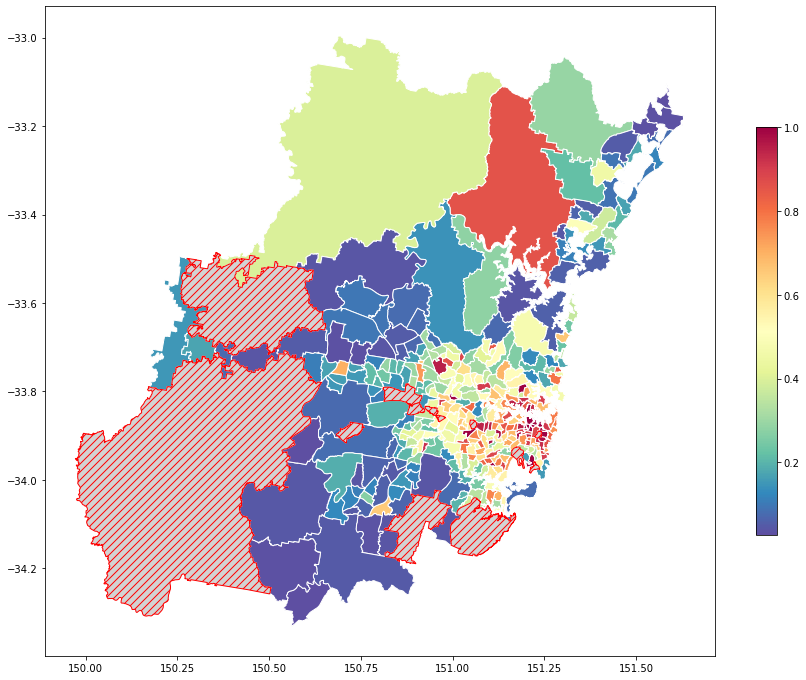

In [29]:
# TOTAL <WELL_SOURCED> SCORE
sa2_sigmoid.plot(
    column="well_resourced",
    legend=True,
    figsize=(15, 15),
    missing_kwds={"color": "lightgrey", "edgecolor": "red",
                    "hatch": "///", "label": "pop <100"}, 
    cmap='Spectral_r', 
    edgecolor = 'white',
    legend_kwds={'shrink': 0.5}
);

## Task 3: Extensions

### 3.1. Clean new data sets

In [30]:
# 3 DATA SETS

In [31]:
#1 toilet <json>
# primary = FacilityID
with open('toiletMap.json') as json_data:
    data = json.load(json_data)
    
fields = data.get('fields')             # heading <list of dictionaries>  
heading = [i.get('id') for i in fields]
records = data.get('records')           # data rows <list of list>
toilet = pd.DataFrame(records)          # convert to df
toilet.columns = heading                # update heading

toilet['geom'] = gpd.points_from_xy(toilet.Longitude, toilet.Latitude)   
toilet = toilet.drop(columns=['Longitude', 'Latitude'])                       
toilet['geom'] = toilet['geom'].apply(lambda x: WKTElement(x.wkt, srid=4326))
# no NaN
toilet = toilet[['FacilityID', 'Name', 'FacilityType', 'Address1', 'Town', 'geom']]

In [32]:
#2 crime <shp>
# primary = OBJECTID, no NaN
crime = gpd.read_file("CrimeHotspots\DomesticAssault_JanToDec2021.shp")

crime['geom'] = crime['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=4326))
crime = crime.drop(columns='geometry')

In [33]:
#3 employees <csv>
employees = pd.read_csv('employees.csv', thousands=',')
# drop row where sa2_code contains NaN, 'w'
employees['sa2_code'] = pd.to_numeric(employees['sa2_code'], errors='coerce')
employees = employees[employees['sa2_code'].notna()]
# only NaN left in numeric column
employees = employees.replace(np.nan, 0)
# covert float to int type
employees['sa2_code'] = employees['sa2_code'].astype('int64')
employees['non_employing'] = employees['non_employing'].astype('int64')
employees['1_to_4_employees'] = employees['1_to_4_employees'].astype('int64')
employees['5_to_19_employees'] = employees['5_to_19_employees'].astype('int64')
employees['20_to_199_employees'] = employees['20_to_199_employees'].astype('int64')
employees['200_to_more_employees'] = employees['200_to_more_employees'].astype('int64')
employees['total'] = employees['total'].astype('int64')

### 3.2. SQL

In [34]:
# CREATE SCHEMA
# 1 toilet <json>
conn.execute("""
DROP TABLE IF EXISTS toilet CASCADE;
CREATE TABLE toilet (
   facilityid VARCHAR(50) PRIMARY KEY,
   name VARCHAR(150),
   facilitytype VARCHAR(150),
   address1 VARCHAR(150),
   town VARCHAR(100),
   geom GEOMETRY(POINT,4326)
);""")

# 2 crime <shp>
conn.execute("""
DROP TABLE IF EXISTS crime CASCADE;
CREATE TABLE crime (
    objectid INTEGER PRIMARY KEY,
    contour FLOAT,
    density VARCHAR(50),
    orig_fid VARCHAR(50),
    shape_leng FLOAT,
    shape_area FLOAT,
    geom GEOMETRY(MULTIPOLYGON,4326)
);"""
)

#3 employees <csv>
conn.execute("""
DROP TABLE IF EXISTS employees CASCADE;
CREATE TABLE employees (
   industry_code VARCHAR(50),
   industry_name VARCHAR(100),
   sa2_code INTEGER,
   sa2_name VARCHAR(100),
   "non_employing" INTEGER,
   "1_to_4_employees" INTEGER,
   "5_to_19_employees" INTEGER,
   "20_to_199_employees" INTEGER,
   "200_to_more_employees" INTEGER,
   total INTEGER
);""")

In [35]:
# INSERT DATA
# 1 toilet
toilet.columns = map(str.lower, toilet.columns)
toilet.to_sql('toilet', conn, if_exists='append', index=False, dtype={'geom': Geometry(geometry_type='POINT', srid=4326)})

# 2 crime
crime.columns = map(str.lower, crime.columns)
crime.to_sql("crime", conn, if_exists='append', index=False, dtype={'geom': Geometry('MULTIPOLYGON', 4326)})

#3 employees
employees.columns = map(str.lower, employees.columns)
employees.to_sql("employees", con=conn, if_exists='append', index=False)

In [36]:
# CREATE INDEX
conn.execute("CREATE INDEX IF NOT EXISTS tid ON toilet USING GIST (geom)")
conn.execute("CREATE INDEX IF NOT EXISTS cgid ON crime USING GIST (geom)")
conn.execute("CREATE INDEX IF NOT EXISTS eid ON employees(sa2_code)")

### 3.3. Added score

In [37]:
# 1 TOILET SCORE
# +score
sa2_toilet = sa2.copy()
s5 = """
SELECT COUNT(facilityid) AS toilet
FROM toilet RIGHT JOIN sa2 on ST_Contains(sa2.geom, toilet.geom)
GROUP BY sa2_code21 
ORDER BY sa2_code21
"""
query_s5 = query(conn, s5)
# score = number of toilet per area_square
sa2_toilet['toilet_score'] = query_s5['toilet'] / sa2['areasqkm21']
# zscore, ignore nan
mu = sa2_toilet['toilet_score'].mean(skipna=True)
sd = sa2_toilet['toilet_score'].std(skipna=True)
# row with toilet = NaN will have zscore = NaN
sa2_toilet['z_toilet_score'] = (sa2_toilet['toilet_score'] - mu) / sd

sa2_toilet.head(1) # geodata frame

,sa2_code21,sa2_name21,areasqkm21,geom,young_people,total_people,toilet_score,z_toilet_score
0,102011028,Avoca Beach - Copacabana,6.4376,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",2121.0,7530.0,0.62135,-0.519089


In [38]:
# 2 CRIME SCORE <DOMESTIC ASSAULT>
# -score
sa2_crime = sa2.copy()
s6 = """
SELECT SUM(shape_area) AS crime
FROM crime RIGHT JOIN sa2 on ST_Overlaps(sa2.geom, crime.geom)
GROUP BY sa2_code21 
ORDER BY sa2_code21
"""
query_s6 = query(conn, s6)
# score = area of  
sa2_crime['crime_score'] = query_s6['crime'].replace(np.nan, 0) / sa2['areasqkm21']
# zscore, ignore nan
mu = sa2_crime['crime_score'].mean(skipna=True)
sd = sa2_crime['crime_score'].std(skipna=True)
sa2_crime['z_crime_score'] = (sa2_crime['crime_score'] - mu) / sd

sa2_crime.head(1) # geodata frame

,sa2_code21,sa2_name21,areasqkm21,geom,young_people,total_people,crime_score,z_crime_score
0,102011028,Avoca Beach - Copacabana,6.4376,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",2121.0,7530.0,0.000002,-0.655542


In [39]:
# 3 CONSTRUCTION_NON_EMPLOYING SCORE
# non employing construction industry per 1000 people
# -score, cuz constraction need large amount of human resources
sa2_construct = sa2.copy()
c1 = """
SELECT sa2_code, non_employing AS construct 
FROM employees RIGHT JOIN population USING (sa2_code)
WHERE industry_name = 'Construction'
GROUP BY sa2_code, construct 
ORDER BY sa2_code
"""
query_c1 = query(conn, c1)
# score
sa2_construct['construct_score'] = query_c1['construct'] / sa2['total_people'] * 1000
# zscore, ignore nan
mu = sa2_construct['construct_score'].mean(skipna=True)
sd = sa2_construct['construct_score'].std(skipna=True)
# row with total_people = NaN will have zscore = NaN
sa2_construct['z_construct_score'] = (sa2_construct['construct_score'] - mu) / sd

sa2_construct.head(1)  # geodata frame

,sa2_code21,sa2_name21,areasqkm21,geom,young_people,total_people,construct_score,z_construct_score
0,102011028,Avoca Beach - Copacabana,6.4376,"MULTIPOLYGON (((151.41373 -33.46558, 151.41362...",2121.0,7530.0,12.4834,0.114459


In [40]:
# NEW SIGMOID SMR
sa2_sigmoid_new = [sa2_retail[['sa2_code21', 'sa2_name21', 'geom', 'z_retail_score']],
                  sa2_health['z_health_score'], sa2_stops['z_stops_score'],
                  sa2_polls['z_polls_score'], sa2_schools['z_schools_score'], sa2_toilet['z_toilet_score'],
                  sa2_crime['z_crime_score'], sa2_construct['z_construct_score']]
sa2_sigmoid_new = pd.concat(sa2_sigmoid_new, axis=1)

# NEW WELL-RESOURCED SCORE
sa2_sigmoid_new['well_resourced'] = 1 / (1 + np.exp(-(sa2_sigmoid_new['z_retail_score'] 
                                        + sa2_sigmoid_new['z_health_score'] + sa2_sigmoid_new['z_stops_score'] 
                                        + sa2_sigmoid_new['z_polls_score'] + sa2_sigmoid_new['z_schools_score']
                                        + sa2_sigmoid_new['z_toilet_score'] - sa2_sigmoid_new['z_crime_score']
                                        - sa2_sigmoid_new['z_construct_score'])))

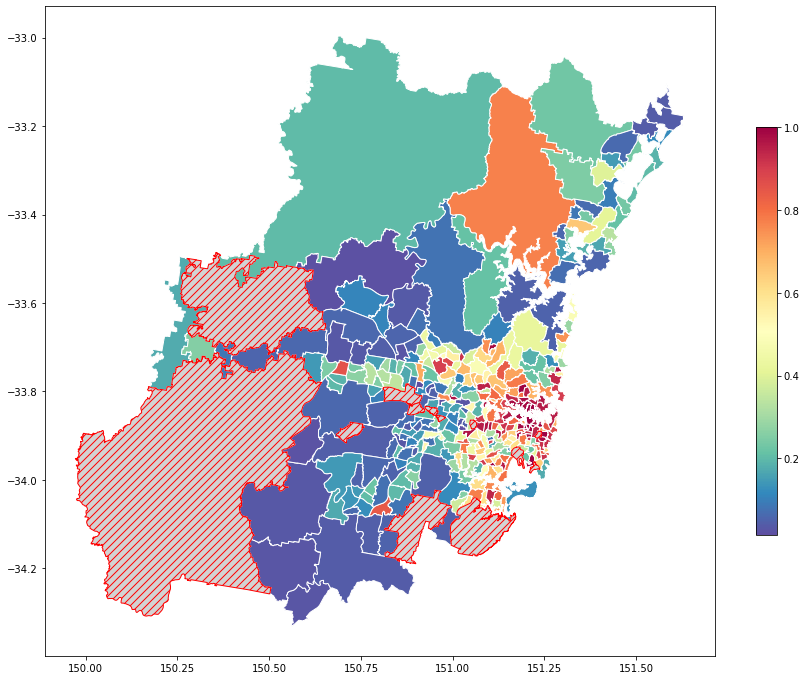

In [41]:
# TOTAL <WELL_SOURCED> SCORE
sa2_sigmoid_new.plot(
    column="well_resourced",
    legend=True,
    figsize=(15, 15),
    missing_kwds={"color": "lightgrey", "edgecolor": "red",
                    "hatch": "///", "label": "pop <100"}, 
    cmap='Spectral_r', 
    edgecolor = 'white',
    legend_kwds={'shrink': 0.5}
);

### 3.4. Corr

In [42]:
merged_income = pd.merge(sa2_sigmoid_new, income, left_on='sa2_code21', right_on='sa2_code')
merged_income[['well_resourced' ,'median_income' ]].corr()

,well_resourced,median_income
well_resourced,1.000000,0.504201
median_income,0.504201,1.000000


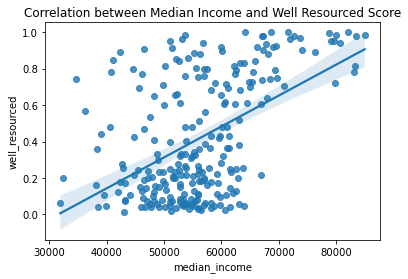

In [43]:
sns.regplot(x='median_income', y='well_resourced', data=merged_income)
plt.title('Correlation between Median Income and Well Resourced Score')
plt.show()

# Based on the plot, the median_income is positively related to well_resourced.
# As median_income increases, the well_resourced score will also increase accordingly.

In [44]:
conn.close()
db.dispose()